In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [124]:
!pip install "darts[xgboost]"
!pip install "darts[prophet]"

In [125]:
df = pd.read_csv('data\electricity_consumption_and_production.csv', parse_dates = ['DateTime'], index_col = 'DateTime', sep = ',')
print(f'Dataset shape: {df.shape}')
df.head(10)

Dataset shape: (54161, 9)


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30
2019-01-01 05:00:00,5525,5385,1395,91,958,1455,1456,0,30
2019-01-01 06:00:00,5513,5349,1392,98,938,1451,1440,0,310
2019-01-01 07:00:00,5524,5547,1392,93,1187,1446,1394,0,34
2019-01-01 08:00:00,5510,5471,1391,51,1325,1357,1303,8,34


In [126]:
def preprocess(df: pd.DataFrame) -> pd.Series:
    series = df["Consumption"]
    series = series[~series.index.duplicated(keep="first")]
    series = series.resample("D").mean()
    full_range = pd.date_range(start = series.index.min(), end = series.index.max(), freq = "D")
    series = series.reindex(full_range).interpolate(method = 'linear')
    return series

consumption_daily = {"Consumption": preprocess(df)}

for name, s in consumption_daily.items():
    print(f"{name:<22} {len(s):>3} days  "
          f"({s.index.min().date()} → {s.index.max().date()})  "
          f"mean={s.mean():.1f} NPR")

Consumption            2270 days  (2019-01-01 → 2025-03-19)  mean=6526.9 NPR


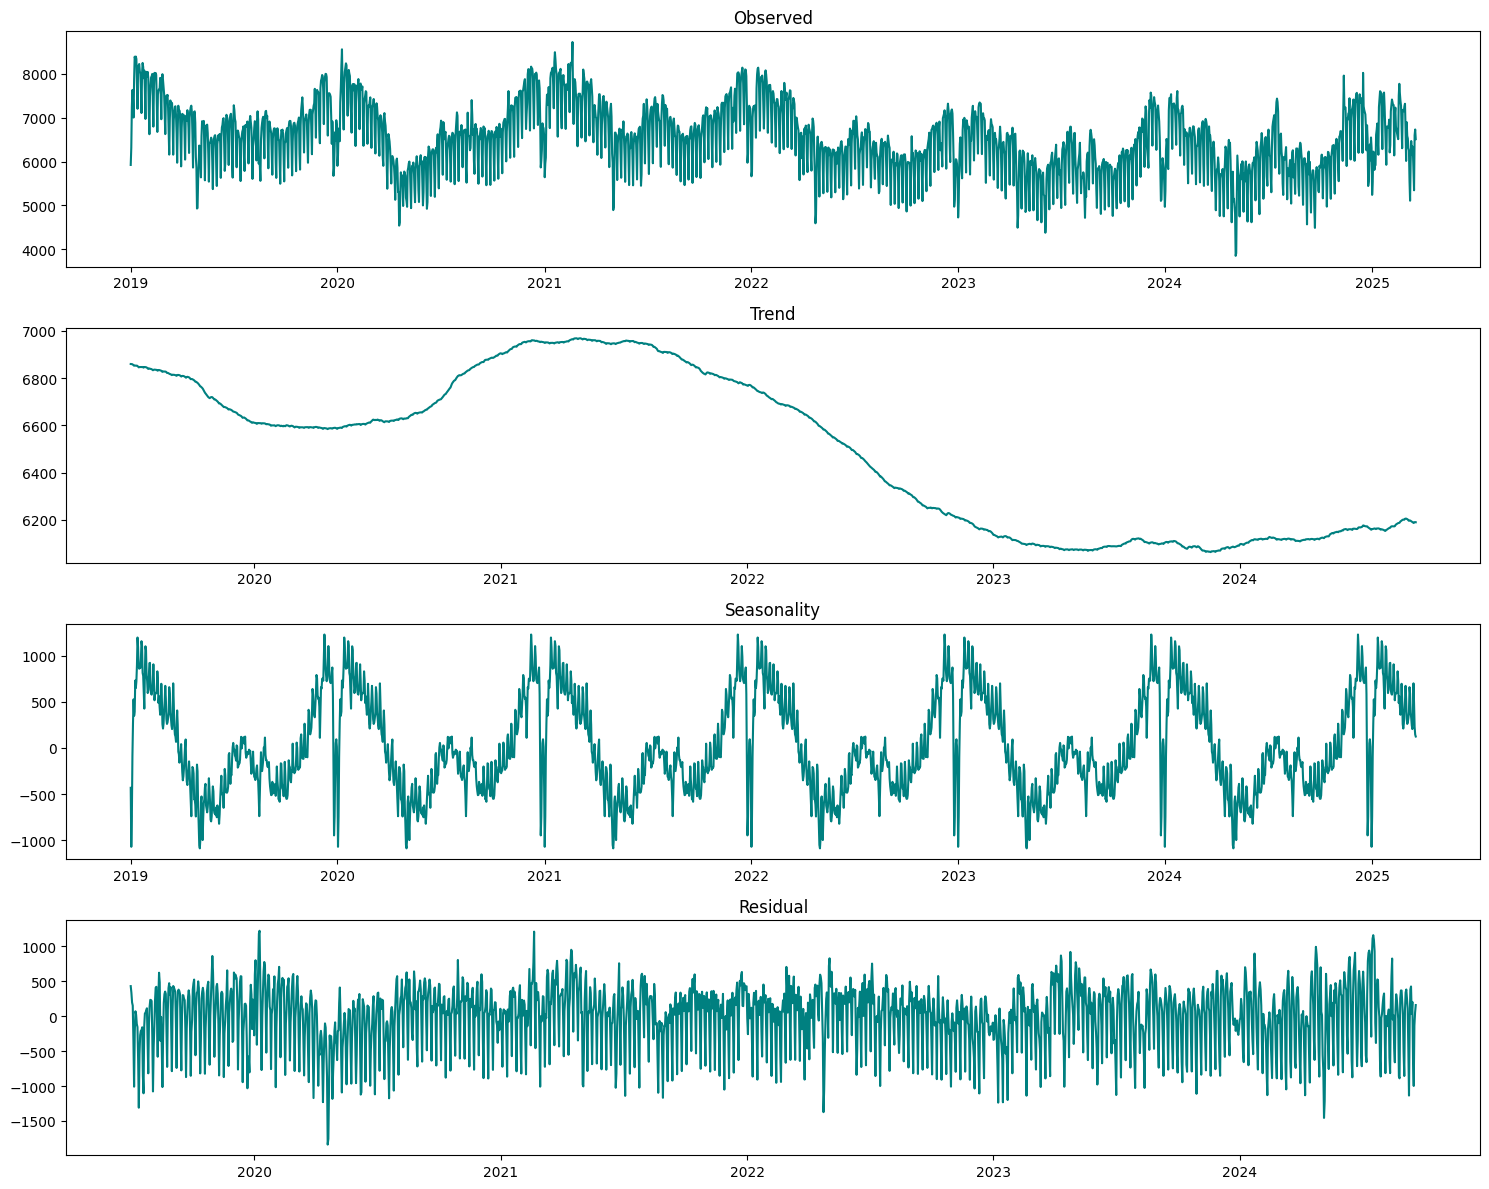

In [127]:
series = consumption_daily['Consumption']
from statsmodels.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(4, 1, figsize = (15, 12))
comp_titles = ['Observed', 'Trend', 'Seasonality', 'Residual']

decomposition = seasonal_decompose(series, model = 'additive', period = 365)
components = [decomposition.observed, decomposition.trend, decomposition.seasonal, decomposition.resid]

for i, ax in enumerate(axes):
    ax.plot(components[i], color = 'teal')
    ax.set_title(comp_titles[i], fontsize = 12)


plt.tight_layout()
plt.show()

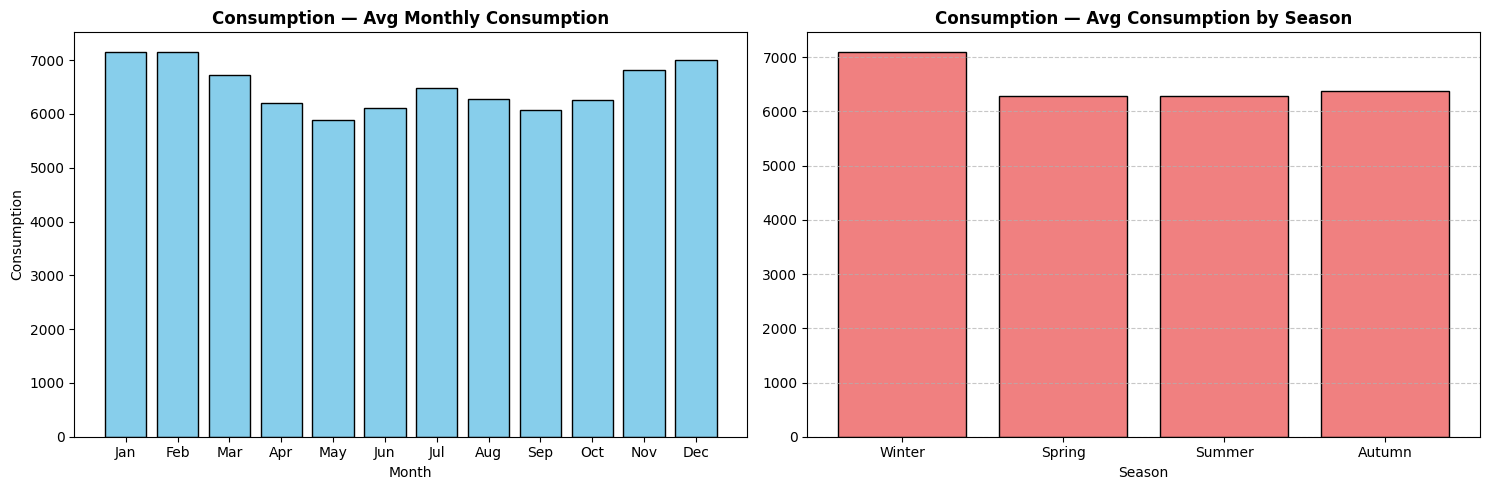

In [128]:
import calendar
SEASONS = {"Winter": [12, 1, 2], "Spring": [3, 4, 5], "Summer": [6, 7, 8], "Autumn": [9, 10, 11]}
num_series = len(consumption_daily)

fig, axes = plt.subplots(num_series, 2, figsize=(15, 5 * num_series), squeeze = False)

for row, (name, series) in enumerate(consumption_daily.items()):
    monthly_avg = series.groupby(series.index.month).mean()
    seasonal_avg = {
        season: series[series.index.month.isin(months)].mean()
        for season, months in SEASONS.items()
    }

    axes[row][0].bar(monthly_avg.index, monthly_avg.values, color="skyblue", edgecolor="black")
    axes[row][0].set_title(f"{name} — Avg Monthly Consumption", fontsize=12, fontweight='bold')
    axes[row][0].set_xlabel("Month", fontsize=10)
    axes[row][0].set_ylabel("Consumption", fontsize=10)

    axes[row][0].set_xticks(range(1, 13))
    axes[row][0].set_xticklabels([calendar.month_abbr[i] for i in range(1, 13)])

    axes[row][1].bar(seasonal_avg.keys(), seasonal_avg.values(), color="lightcoral", edgecolor="black")
    axes[row][1].set_title(f"{name} — Avg Consumption by Season", fontsize=12, fontweight='bold')
    axes[row][1].set_xlabel("Season", fontsize=10)
    axes[row][1].grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

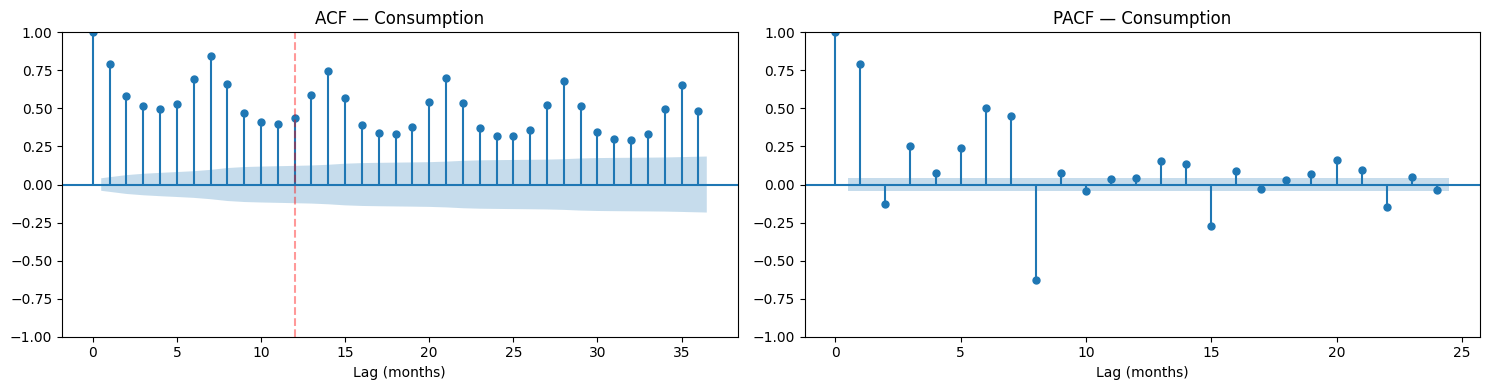

In [129]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(num_series, 2, figsize = (15, 4 * num_series), squeeze = False)
for row, (name, series) in enumerate(consumption_daily.items()):
    plot_acf(series, lags=36, ax=axes[row, 0], title=f"ACF — {name}")
    axes[row, 0].axvline(x=12, color="red", linestyle="--", alpha=0.4)
    axes[row, 0].set_xlabel("Lag (months)")

    plot_pacf(series, lags=24, method="ywm", ax=axes[row, 1], title=f"PACF — {name}")
    axes[row, 1].set_xlabel("Lag (months)")

plt.tight_layout()
plt.show()


In [130]:
from statsmodels.tsa.stattools import adfuller

def adf_stationarity_test(series: pd.Series) -> dict:
    result = adfuller(series)
    p_value = result[1]
    return {"ADF Statistic": round(result[0], 4), "p-value": round(p_value, 4),
            "Stationary": p_value < 0.05}

adf_results = {name: adf_stationarity_test(s) for name, s in consumption_daily.items()}
pd.DataFrame(adf_results).T.style.map(
    lambda v: "background-color: lightgreen" if v is True else
              "background-color: #ffcccb"    if v is False else "",
    subset=["Stationary"]
)

,ADF Statistic,p-value,Stationary
Consumption,-3.387800,0.011400,True


In [131]:
from darts import TimeSeries
from darts.metrics import mape, mae, mse, mql
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

consumption_ts = {name: TimeSeries.from_series(s, freq = "D") for name, s in consumption_daily.items()}

TEST_SIZE = 45
train_split = {name: ts[:-TEST_SIZE] for name, ts in consumption_ts.items()}
val_split = {name: ts[-TEST_SIZE:] for name, ts in consumption_ts.items()}

series_name = list(consumption_ts.keys())
ref_name = series_name[0]
ref_train = train_split[ref_name]
ref_val = val_split[ref_name]

print(f'Avaliable time series: {series_name}')
print(f'Reference for tuning: {ref_name}')
print(f'Train / Val sizes: {len(ref_train)} / {len(ref_val)}')

Avaliable time series: ['Consumption']
Reference for tuning: Consumption
Train / Val sizes: 2225 / 45


In [132]:
def calculate_metrics(actual_ts, pred_ts, q_low=0.1, q_high=0.9):
    is_prob = pred_ts.n_samples > 1
    median = pred_ts.quantile(0.5) if is_prob else pred_ts
    return {
        "MAPE (%)": round(mape(actual_ts, median), 3),
        "MAE":      round(mae(actual_ts, median), 3),
        "MSE":      round(mse(actual_ts, median), 3),
        f"QL@{q_low}":  round(mql(actual_ts, pred_ts, q=q_low),  3) if is_prob else None,
        f"QL@{q_high}": round(mql(actual_ts, pred_ts, q=q_high), 3) if is_prob else None,
    }


def visualize_multi_forecast(model_name, predictions, q_low=0.1, q_high=0.9):

    n = len(predictions)
    fig, axes = plt.subplots(n, 1, figsize=(14, 4.5 * n))
    if n == 1:
        axes = [axes]
    all_metrics = {}

    for ax, (name, pred_ts) in zip(axes, predictions.items()):
        train_ts  = train_split[name]
        actual_ts = val_split[name]
        is_prob   = pred_ts.n_samples > 1
        median    = pred_ts.quantile(0.5) if is_prob else pred_ts

        train_ts.to_series().plot(ax=ax, label="Training data", color="steelblue", lw=1.8)
        actual_ts.to_series().plot(ax=ax, label="Actual values", color="green",    lw=1.8)
        median.to_series().plot(   ax=ax, label="Forecast (median)", color="tomato",    lw=1.8)

        if is_prob:
            low  = pred_ts.quantile(q_low).values()[:, 0]
            high = pred_ts.quantile(q_high).values()[:, 0]
            ax.fill_between(
                pred_ts.time_index, low, high,
                alpha=0.25, color="tomato",
                label=f"{int((1 - 2*q_low)*100)}% CI"
            )

        ax.set_title(f"{model_name} — {name}", fontsize=11, fontweight="bold")
        ax.set_ylabel("Price (NPR)")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper left", fontsize=8)

        metrics = calculate_metrics(actual_ts, pred_ts, q_low, q_high)
        all_metrics[name] = metrics

        summary = f"MAPE {metrics['MAPE (%)']:.1f}%  |  MAE {metrics['MAE']:.1f}"
        if metrics[f"QL@{q_low}"] is not None:
            summary += f"  |  QL@{q_low} {metrics[f'QL@{q_low}']:.1f}  QL@{q_high} {metrics[f'QL@{q_high}']:.1f}"
        ax.text(0.99, 0.97, summary, transform=ax.transAxes, fontsize=9,
                ha="right", va="top",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray", boxstyle="round,pad=0.4"))

    plt.tight_layout()
    plt.show()
    return all_metrics

In [133]:
from darts.models import ARIMA

def sarima_objective(trial):
    p = trial.suggest_int("p", 0, 3)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 3)
    P = trial.suggest_int("P", 0, 2)
    D = trial.suggest_int("D", 0, 1)
    Q = trial.suggest_int("Q", 0, 2)
    try:
        model = ARIMA(p=p, d=d, q=q, seasonal_order=(P, D, Q, 7))
        model.fit(ref_train)
        pred = model.predict(n=len(ref_val))
        return mape(ref_val, pred)
    except Exception:
        return float("inf")

study_sarima = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_sarima.optimize(sarima_objective, n_trials=20, show_progress_bar=True)
print(f"\nBest MAPE on '{ref_name}': {study_sarima.best_value:.2f}%")
print(f"Best params: {study_sarima.best_params}")

  0%|          | 0/20 [00:00<?, ?it/s]


Best MAPE on 'Consumption': 5.38%
Best params: {'p': 2, 'd': 0, 'q': 0, 'P': 2, 'D': 1, 'Q': 2}


In [134]:
sarima_predictions = {}
bp = study_sarima.best_params

for name, train_ts in train_split.items():
    model = ARIMA(p=bp["p"], d=bp["d"], q=bp["q"],
                  seasonal_order=(bp["P"], bp["D"], bp["Q"], 7))
    model.fit(train_ts)
    sarima_predictions[name] = model.predict(n=TEST_SIZE, num_samples=500)
    print(f"  ✓")

  ✓


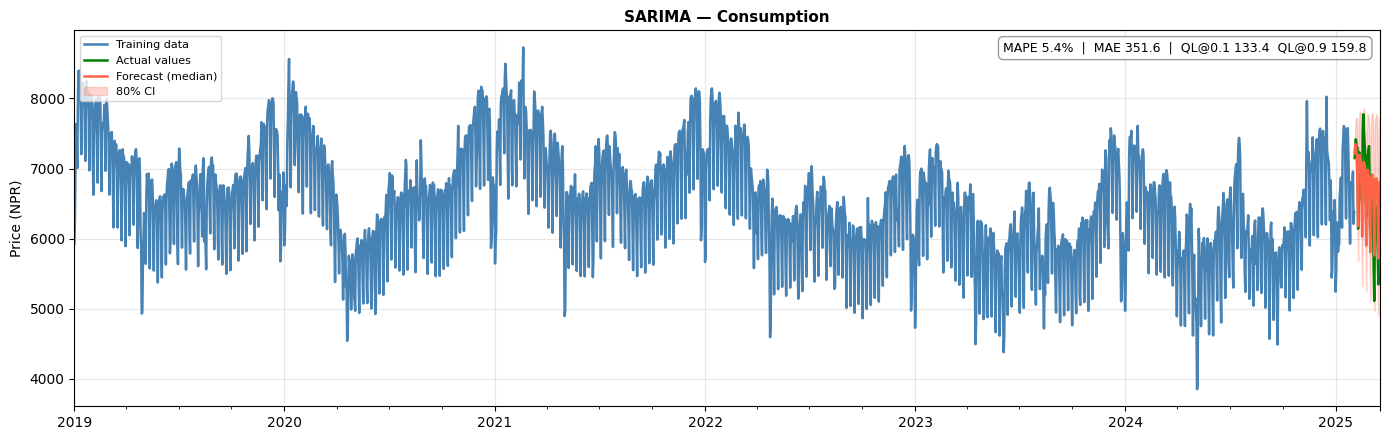

In [135]:
sarima_all_metrics = visualize_multi_forecast("SARIMA", sarima_predictions)

In [136]:
from darts.models import ExponentialSmoothing
from darts.utils.utils import ModelMode, SeasonalityMode

TREND_MAP    = {"additive": ModelMode.ADDITIVE, "multiplicative": ModelMode.MULTIPLICATIVE, "none": ModelMode.NONE}
SEASONAL_MAP = {"additive": SeasonalityMode.ADDITIVE, "multiplicative": SeasonalityMode.MULTIPLICATIVE}

def es_objective(trial):
    trend_str    = trial.suggest_categorical("trend",    ["additive", "multiplicative", "none"])
    seasonal_str = trial.suggest_categorical("seasonal", ["additive", "multiplicative"])
    damped       = trial.suggest_categorical("damped",   [True, False])
    if trend_str == "none" and damped:
        return float("inf")
    try:
        model = ExponentialSmoothing(
            trend=TREND_MAP[trend_str], seasonal=SEASONAL_MAP[seasonal_str],
            damped=damped, seasonal_periods=7,
        )
        model.fit(ref_train)
        pred = model.predict(n=len(ref_val))
        return mape(ref_val, pred)
    except Exception:
        return float("inf")

study_es = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_es.optimize(es_objective, n_trials=20, show_progress_bar=True)
print(f"\nBest MAPE on '{ref_name}': {study_es.best_value:.2f}%")
print(f"Best params: {study_es.best_params}")

  0%|          | 0/20 [00:00<?, ?it/s]


Best MAPE on 'Consumption': 7.34%
Best params: {'trend': 'multiplicative', 'seasonal': 'additive', 'damped': False}


In [137]:
es_predictions = {}
bp = study_es.best_params

for name, train_ts in train_split.items():
    model = ExponentialSmoothing(
        trend=TREND_MAP[bp["trend"]], seasonal=SEASONAL_MAP[bp["seasonal"]],
        damped=bp["damped"], seasonal_periods=7,
    )
    model.fit(train_ts)
    es_predictions[name] = model.predict(n=TEST_SIZE, num_samples=500)
    print(f"  ✓")

  ✓


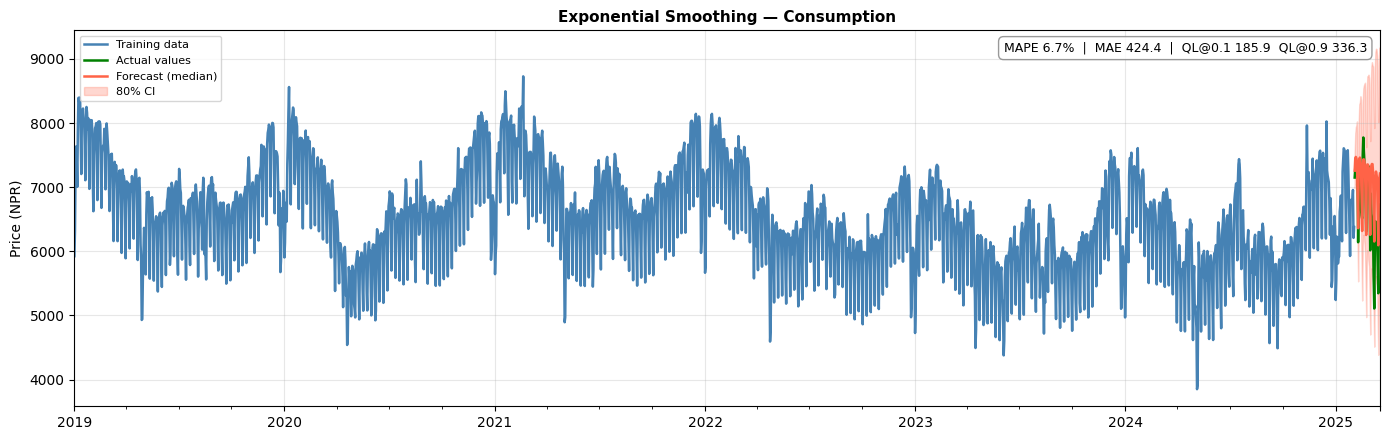

In [138]:
es_all_metrics = visualize_multi_forecast("Exponential Smoothing", es_predictions)

In [139]:
from darts.models import Chronos2Model
from darts.utils.likelihood_models.torch import QuantileRegression

chronos_model = Chronos2Model(
    model_name="amazon/chronos-bolt-base",
    input_chunk_length=36,
    output_chunk_length=TEST_SIZE,
    likelihood=QuantileRegression([0.1, 0.5, 0.9])
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Chronos fitted on 1 series (zero-shot, weights unchanged)


Predicting: |          | 0/? [00:00<?, ?it/s]

  ✓


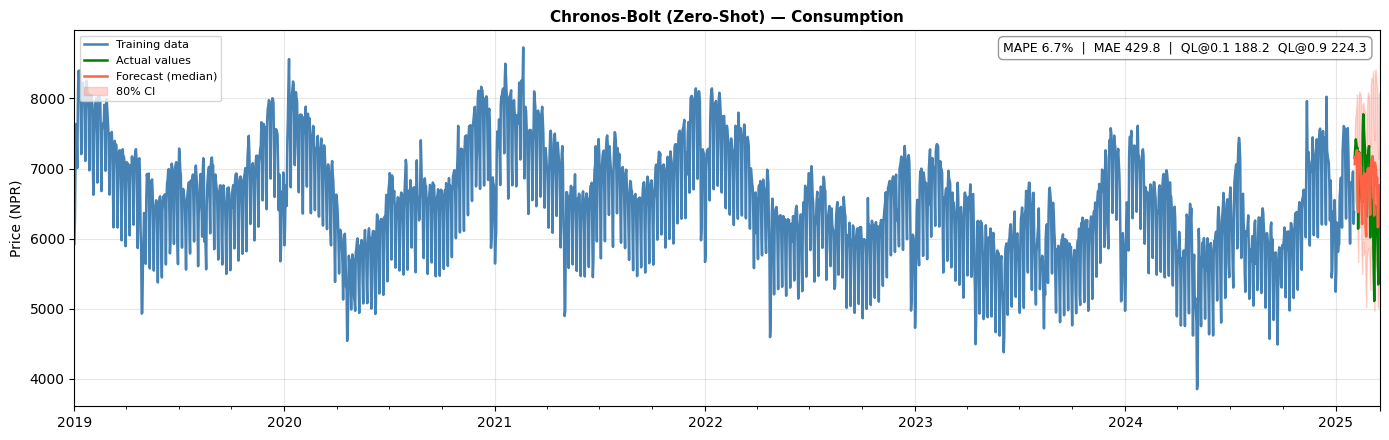

,MAPE (%),MAE,MSE,QL@0.1,QL@0.9
Consumption,6.681000,429.777000,277337.805000,188.199000,224.314000


In [140]:
train_series_list = list(train_split.values())
chronos_model.fit(train_series_list)  
print(f"Chronos fitted on {len(train_series_list)} series (zero-shot, weights unchanged)")

chronos_predictions = {}
for name, train_ts in train_split.items():
    pred = chronos_model.predict(
        n=TEST_SIZE,
        series=train_ts,
        num_samples=500
    )
    chronos_predictions[name] = pred
    print(f"  ✓")
    chronos_metrics = visualize_multi_forecast("Chronos-Bolt (Zero-Shot)", chronos_predictions)
    metrics_df = pd.DataFrame(chronos_metrics).T
    display(metrics_df.style.background_gradient(cmap="RdYlGn_r", subset=["MAPE (%)"]))

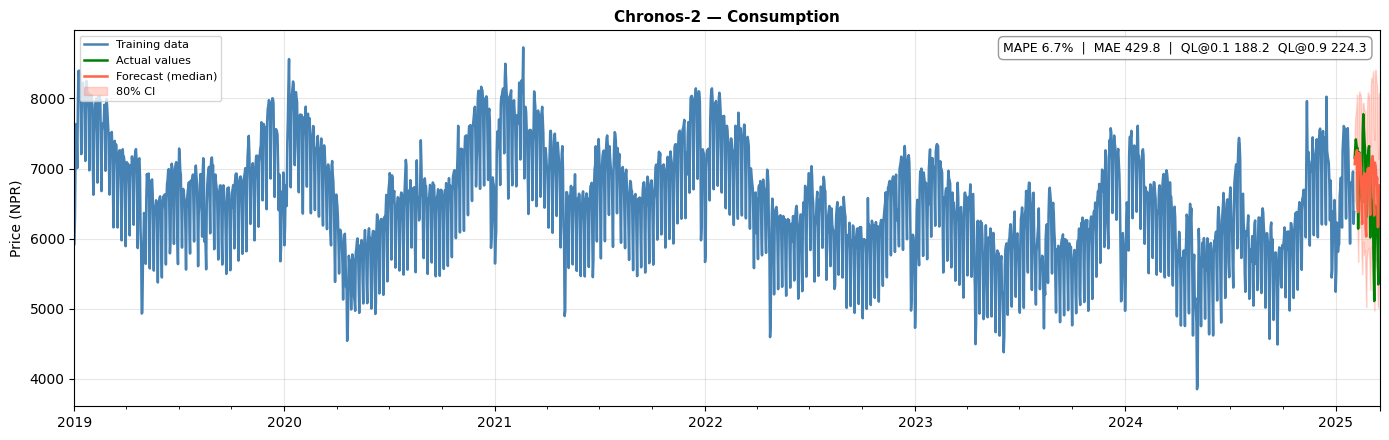

In [141]:
chronos_all_metrics = visualize_multi_forecast("Chronos-2", chronos_predictions)

In [142]:
model_results = {
    "SARIMA":         sarima_all_metrics,
    "Exp. Smoothing": es_all_metrics,
    "Chronos-Bolt":   chronos_all_metrics,
}

rows = []
for model_name, metrics_by_cons in model_results.items():
    for commodity, m in metrics_by_cons.items():
        for metric, val in m.items():
            rows.append({"Model": model_name, "Metric": metric, "Commodity": commodity, "Value": val})

results_df = pd.DataFrame(rows)

pivot = results_df.pivot_table(index=["Model", "Metric"], values= 'Value')
pivot

Value
Model          Metric              
Chronos-Bolt   MAE          429.777
               MAPE (%)       6.681
               MSE       277337.805
               QL@0.1       188.199
               QL@0.9       224.314
Exp. Smoothing MAE          424.357
               MAPE (%)       6.738
               MSE       308715.598
               QL@0.1       185.896
               QL@0.9       336.295
SARIMA         MAE          351.556
               MAPE (%)       5.383
               MSE       170638.414
               QL@0.1       133.367
               QL@0.9       159.787

In [143]:
all_predictions = {
    "SARIMA": sarima_predictions["Consumption"],
    "Exp. Smoothing": es_predictions["Consumption"],
    "Chronos-Bolt": chronos_predictions["Consumption"]
}

horizons = [15, 30, 45]
evaluation_results = []

actual = val_split["Consumption"]

for model_name, pred_full in all_predictions.items():
    for h in horizons:
        h_int = int(h) 
        
        start = pred_full.start_time()
        end = start + pd.Timedelta(days=h_int - 1)
  
        pred_h = pred_full.slice(start, end)
        actual_h = actual.slice(start, end)

        mape_score = mape(actual_h, pred_h)
        evaluation_results.append({
            "Model": model_name, 
            "Horizon (days)": h_int, 
            "MAPE (%)": mape_score
        })

df_results = pd.DataFrame(evaluation_results)

pivot_df = df_results.pivot_table(index="Model", columns="Horizon (days)", values="MAPE (%)")

display(
    pivot_df.style
    .background_gradient(cmap="RdYlGn_r", axis=None) 
    .format("{:.2f}%")
)



Horizon (days),15,30,45
Model,,,
Chronos-Bolt,3.62%,4.61%,6.68%
Exp. Smoothing,4.14%,3.21%,6.74%
SARIMA,3.46%,4.19%,5.38%
